# Reproductions of Juno result

Step-by-step reproduction of Figures 2 and 4 (all physics, constants, and the needed covariance data are embedded). Only `numpy` and `matplotlib` are required dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogFormatterMathtext

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

# Set the values of constants
G_SI = 6.67430e-11
C_KM_S = 299_792.458
C_M_S = C_KM_S * 1.0e3
HBAR_EV_S = 6.582_119_569e-16

MU_KM = 1.266_865_341e8          # GM for Jupiter in units of km^3/s^2
MU_M = MU_KM * 1.0e9
M_JUP_KG = MU_M / G_SI
R_J_KM = 71_492.0
R_J_M = R_J_KM * 1.0e3

# Orbital parameters of Juno estimated from perijove 1 through perijove 17
T_ORBIT_S = 53.5 * 86_400.0
A_KM = (MU_KM * T_ORBIT_S**2 / (4.0 * np.pi**2)) ** (1.0 / 3.0)
A_M = A_KM * 1.0e3
ECC = 1.0 - 1.06 * R_J_KM / A_KM
INC, OMEGA = 1.57, 3.08
N_MAX = 10

print(f"a = {A_KM:.4e} km ({A_KM/R_J_KM:.1f} R_J), e = {ECC:.5f}, 1-e = {1-ECC:.5f}")

a = 4.0929e+06 km (57.3 R_J), e = 0.98148, 1-e = 0.01852


## Gravity precession derivatives (Appendix B + GR term)

`d<dw_g>/dJ_l` for `l=2..10` (linear-in-`J_l` coefficients of eqs. B.1-B.9) plus the GR `d/dmu` term.

In [2]:
def _trig(inc, omega):
    return dict(
        cos_i=np.cos(inc), sin_i=np.sin(inc), csc_i=1.0/np.sin(inc),
        cos3i=np.cos(3*inc), cos5i=np.cos(5*inc),
        cos2i=np.cos(2*inc), cos4i=np.cos(4*inc), cos6i=np.cos(6*inc),
        cos8i=np.cos(8*inc), cos10i=np.cos(10*inc),
        sin2i=np.sin(2*inc), sin3i=np.sin(3*inc), sin4i=np.sin(4*inc), sin5i=np.sin(5*inc),
        sin_w=np.sin(omega), sin3w=np.sin(3*omega), sin5w=np.sin(5*omega), sin7w=np.sin(7*omega),
        cos2w=np.cos(2*omega), cos4w=np.cos(4*omega), cos6w=np.cos(6*omega), cos8w=np.cos(8*omega),
    )

def domega_dJl(l, a, e, inc, omega, RJ):
    """Coefficient of J_l in eqs. B.1-B.9 = d<dw_g>/dJ_l (unnormalised)."""
    e2, e4, e6, e8 = e**2, e**4, e**6, e**8
    em1 = e**2 - 1.0
    t = _trig(inc, omega); pi = np.pi
    cos_i, sin_i, csc_i = t["cos_i"], t["sin_i"], t["csc_i"]
    cos3i, cos5i = t["cos3i"], t["cos5i"]
    cos2i, cos4i, cos6i, cos8i, cos10i = t["cos2i"], t["cos4i"], t["cos6i"], t["cos8i"], t["cos10i"]
    sin2i, sin3i, sin4i, sin5i = t["sin2i"], t["sin3i"], t["sin4i"], t["sin5i"]
    sin_w, sin3w, sin5w, sin7w = t["sin_w"], t["sin3w"], t["sin5w"], t["sin7w"]
    cos2w, cos4w, cos6w, cos8w = t["cos2w"], t["cos4w"], t["cos6w"], t["cos8w"]

    if l == 2:
        return 3*pi*(3+5*cos2i)*RJ**2/(4*a**2*em1**2)
    if l == 3:
        return (3*pi*(-1-3*e2-4*cos2i+5*(1+7*e2)*cos4i)*csc_i*sin_w*RJ**3/(32*a**3*e*em1**3))
    if l == 4:
        return (1.0/(512*a**4*em1**4))*15*pi*(
            -27*(4+5*e2) + 2*(-6+5*e2)*cos2w
            + 4*cos2i*(-52-63*e2+2*(-2+7*e2)*cos2w)
            + 7*cos4i*(-28-27*e2+2*(2+9*e2)*cos2w))*RJ**4
    if l == 5:
        return (1.0/(1024*a**5*e*em1**5))*15*pi*(
            (4+41*e2+18*e4)*(2*sin_i+7*(sin3i+3*sin5i))*sin_w
            + 28*e2*(1+2*e2)*(7+9*cos2i)*sin_i**3*sin3w
            - e2*cos_i*((4+3*e2)*(2*cos_i+21*(cos3i+5*cos5i))*csc_i*sin_w
                        + 7*e2*(2*sin2i+15*sin4i)*sin3w))*RJ**5
    if l == 6:
        return (1.0/(32768*a**6*em1**6))*105*pi*(
            2256*cos4i + 2376*cos6i
            + 5*((472+1940*e2+675*e4)*cos2i + 3*e2*(2*(292+99*e2)*cos4i+11*(44+13*e2)*cos6i))
            - 5*(10*e2*(6+7*e2)+(-68+254*e2+195*e4)*cos2i+6*(-4+102*e2+55*e4)*cos4i
                 +33*(4+34*e2+13*e4)*cos6i)*cos2w
            + 50*(24+100*e2+35*e4+4*cos2w)
            - 6*e2*(-28+45*e2+4*(-4+33*e2)*cos2i+11*(4+13*e2)*cos4i)*cos4w*sin_i**2)*RJ**6
    if l == 7:
        return (1.0/(524288*a**7*e*em1**7))*21*pi*sin_i**3*(
            -5*(25*(8+148*e2+205*e4+35*e6)+(448+6592*e2+7240*e4+900*e6)*cos2i
                +12*(56-5*e2*(-76+41*e2+33*e4))*cos4i-132*(-16-80*e2+65*e4*(2+e2))*cos6i
                -429*(8+212*e2+365*e4+75*e6)*cos8i)*csc_i**4*sin_w
            + 30*e2*(14*(15+7*e2)*(-8+27*e2)+(-2280+13687*e2+6237*e4)*cos2i
                     +22*(24+967*e2+351*e4)*cos4i+143*(24+151*e2+45*e4)*cos6i)*csc_i**2*sin3w
            + 264*e4*(-45+77*e2+4*(-5+52*e2)*cos2i+65*(1+3*e2)*cos4i)*sin5w)*RJ**7
    if l == 8:
        return (1.0/(16777216*a**8*em1**8))*63*pi*(
            5*(-1225*(192+35*e2*(48+56*e2+9*e4))
               -280*(1664+7*e2*(2064+2400*e2+385*e4))*cos2i
               -308*(1472+7*e2*(1776+2040*e2+325*e4))*cos4i
               -3432*(128+7*e2*(144+160*e2+25*e4))*cos6i
               -715*(704+7*e2*(624+600*e2+85*e4))*cos8i)
            + 70*(35*(-96+208*e2+950*e4+225*e6)+16*(-384+1648*e2+5160*e4+1155*e6)*cos2i
                  +44*(-96+1360*e2+2870*e4+585*e6)*cos4i+2288*e2*(48+80*e2+15*e4)*cos6i
                  +143*(96+1328*e2+1610*e4+255*e6)*cos8i)*cos2w
            + 616*e2*(6*(-280+944*e2+363*e4)+(-1960+14128*e2+4797*e4)*cos2i
                      +26*(40+688*e2+195*e4)*cos4i+65*(40+208*e2+51*e4)*cos6i)*cos4w*sin_i**2
            + 4576*e4*(-22+39*e2+4*(-2+25*e2)*cos2i+5*(6+17*e2)*cos4i)*cos6w*sin_i**4)*RJ**8
    if l == 9:
        return (1.0/(67108864*a**9*e*em1**9))*45*pi*sin_i**5*(
            7*(98*(64+1968*e2+5768*e4+3325*e6+315*e8)
               +14*(960+25808*e2+67032*e4+33635*e6+2695*e8)*cos2i
               -88*(-192-3344*e2-3864*e4+1225*e6+455*e8)*cos4i
               -429*(-64+7*e2*(-80+232*e2+405*e4+65*e6))*cos6i
               -286*(-320+7*e2*(-528+488*e2+1465*e4+255*e6))*cos8i
               -2431*(64+2608*e2+9128*e4+6125*e6+665*e8)*cos10i)*csc_i**6*sin_w
            - 4312*e2*(21*(-80+372*e2+705*e4+121*e6)+28*(-96+712*e2+1178*e4+195*e6)*cos2i
                       +52*(-16+580*e2+773*e4+119*e6)*cos4i+52*(32+744*e2+834*e4+119*e6)*cos6i
                       +221*(16+156*e2+147*e4+19*e6)*cos8i)*csc_i**4*sin3w
            - 32032*e4*(22*(-12+43*e2+13*e4)+(-276+2213*e2+605*e4)*cos2i
                        +(200+2462*e2+578*e4)*cos4i+17*(20+91*e2+19*e4)*cos6i)*csc_i**2*sin5w
            - 4576*e6*(-91+165*e2+4*(-7+102*e2)*cos2i+17*(7+19*e2)*cos4i)*sin7w)*RJ**9
    if l == 10:
        return (1.0/(2147483648*a**10*em1**10))*495*pi*(
            7*(23814*(128+3*e2*(640+1568*e2+840*e4+77*e6))
               +294*(20608+307584*e2+751968*e4+402360*e6+36855*e8)*cos2i
               +312*(19072+279936*e2+679392*e4+362040*e6+33075*e8)*cos4i
               +1053*(5504+21*e2*(3712+8864*e2+4680*e4+425*e6))*cos6i
               +442*(12928+21*e2*(8064+18528*e2+9560*e4+855*e6))*cos8i
               +4199*(1664+3*e2*(5760+7*e2*(1632+760*e2+63*e4)))*cos10i)
            - 84*(294*(-192+544*e2+6020*e4+4802*e6+539*e8)
                  +98*(-1088+5344*e2+42028*e4+32158*e6+3549*e8)*cos2i
                  +104*(-832+10720*e2+55356*e4+39102*e6+4165*e8)*cos4i
                  +13*(-3648+156640*e2+626444*e4+411278*e6+42245*e8)*cos6i
                  +442*(64+7328*e2+24276*e4+14826*e6+1463*e8)*cos8i
                  +4199*(64+1312*e2+3220*e4+1666*e6+147*e8)*cos10i)*cos2w
            - 8736*e2*(33*(-224+1208*e2+1600*e4+221*e6)+24*(-448+3896*e2+4680*e4+627*e6)*cos2i
                       +4*(-224+30040*e2+30432*e4+3825*e6)*cos4i+136*(64+920*e2+808*e4+95*e6)*cos6i
                       +323*(32+248*e2+192*e4+21*e6)*cos8i)*cos4w*sin_i**2
            - 1248*e4*(26*(-924+3418*e2+855*e4)+(-23100+199186*e2+45747*e4)*cos2i
                       +238*(84+850*e2+171*e4)*cos4i+323*(84+346*e2+63*e4)*cos6i)*cos6w*sin_i**4
            - 7072*e6*(-120+221*e2+4*(-8+133*e2)*cos2i+19*(8+21*e2)*cos4i)*cos8w*sin_i**6)*RJ**10
    raise ValueError(l)

def domega_dmu(a, e):
    return 6.0*np.pi/(a*(1.0-e**2)*C_KM_S**2)

def gradient_vector(a, e, inc, omega, RJ, n_max=10, apply_normalization=False):
    """[d/dmu, d/dJ2, ..., d/dJ_nmax]. apply_normalization=False reproduces the paper."""
    grad = [domega_dmu(a, e)]
    for l in range(2, n_max + 1):
        d = domega_dJl(l, a, e, inc, omega, RJ)
        if apply_normalization:
            d *= np.sqrt(2*l + 1)
        grad.append(d)
    return np.array(grad)

## Covariance matrix and sigma_omega (eq. 3.5)

The `[GM, J2..J10]` block of the Durante covariance is embedded below, then contracted with the gradient. Those coefficients are fully-normalised; the paper's value is reproduced by contracting them directly with the unnormalised-form derivatives (`apply_normalization=False`).

In [3]:
# [GM, J2, ..., J10] covariance matrix extracted from the supporting data file
# included in the link to the Durante paper, with only the relevant 10 by 10 included.
COV_GM_J = np.array([
    [70.46, 2.318e-09, -4.629e-11, -1.584e-10, -2.058e-11, 2.678e-11, -4.552e-11, 7.314e-11, -1.096e-10, 2.1e-10],
    [2.318e-09, 5.703e-19, -4.222e-19, 2.918e-19, -3.743e-19, 4.109e-19, -5.579e-19, 6.234e-19, -8.617e-19, 9.329e-19],
    [-4.629e-11, -4.222e-19, 1.541e-18, -5.734e-19, 1.156e-18, -1.152e-18, 1.814e-18, -2.355e-18, 3.183e-18, -4.705e-18],
    [-1.584e-10, 2.918e-19, -5.734e-19, 6.411e-19, -7.783e-19, 1.182e-18, -1.416e-18, 2.131e-18, -2.469e-18, 3.625e-18],
    [-2.058e-11, -3.743e-19, 1.156e-18, -7.783e-19, 1.614e-18, -1.956e-18, 3.27e-18, -4.267e-18, 6.421e-18, -8.559e-18],
    [2.678e-11, 4.109e-19, -1.152e-18, 1.182e-18, -1.956e-18, 3.418e-18, -4.95e-18, 8.233e-18, -1.134e-17, 1.798e-17],
    [-4.552e-11, -5.579e-19, 1.814e-18, -1.416e-18, 3.27e-18, -4.95e-18, 9.162e-18, -1.392e-17, 2.286e-17, -3.384e-17],
    [7.314e-11, 6.234e-19, -2.355e-18, 2.131e-18, -4.267e-18, 8.233e-18, -1.392e-17, 2.529e-17, -3.929e-17, 6.622e-17],
    [-1.096e-10, -8.617e-19, 3.183e-18, -2.469e-18, 6.421e-18, -1.134e-17, 2.286e-17, -3.929e-17, 6.932e-17, -1.124e-16],
    [2.1e-10, 9.329e-19, -4.705e-18, 3.625e-18, -8.559e-18, 1.798e-17, -3.384e-17, 6.622e-17, -1.124e-16, 2.001e-16],
])

def covariance_slice(n_max=10):
    return COV_GM_J[:n_max, :n_max]

def sigma_omega(a=A_KM, e=ECC, inc=INC, omega=OMEGA, RJ=R_J_KM, n_max=N_MAX,
                apply_normalization=False):
    g = gradient_vector(a, e, inc, omega, RJ, n_max, apply_normalization)
    return np.sqrt(g @ covariance_slice(n_max) @ g)

SIGMA_OMEGA = sigma_omega()
print(f"sigma_omega (N=10) = {SIGMA_OMEGA:.3e}   [paper ~9.0e-10]")
print("sigma_omega vs N:", {n: round(float(sigma_omega(n_max=n)), 12) for n in (2, 4, 6, 8, 10)})

sigma_omega (N=10) = 9.332e-10   [paper ~9.0e-10]
sigma_omega vs N: {2: 8.07e-10, 4: 8.84e-10, 6: 9.16e-10, 8: 9.29e-10, 10: 9.33e-10}


## Density profile and fifth-force precession (eqs. 2.3-2.5)

Calculate the volume integral numerically from the above equation

In [4]:
def polytrope_n1(n_points=1500, R=R_J_M, total_mass=M_JUP_KG):
    r = np.linspace(0.0, R, n_points)
    x = np.pi * r / R
    shape = np.ones_like(x)
    shape[x > 0] = np.sin(x[x > 0]) / x[x > 0]
    shape = np.clip(shape, 0.0, None)
    m = np.trapezoid(4.0 * np.pi * r**2 * shape, r)
    return r, shape * (total_mass / m)

def g_finite_size(lam_m, a_m=A_M, e=ECC, n_f=1440):
    """Per-orbit g(lambda) = <Delta omega>/alpha including Jupiter's finite size."""
    lam = np.atleast_1d(np.asarray(lam_m, dtype=float))
    rp, rho = polytrope_n1()
    M = np.trapezoid(4.0 * np.pi * rp**2 * rho, rp)
    f = np.linspace(0.0, 2.0 * np.pi, n_f)
    r = a_m * (1.0 - e**2) / (1.0 + e * np.cos(f))
    cosf = np.cos(f); rho_rp = rho * rp
    out = np.empty_like(lam)
    for k, L in enumerate(lam):
        kernel = 0.5 * (np.exp((rp[None, :] - r[:, None]) / L)
                        - np.exp(-(rp[None, :] + r[:, None]) / L))
        inner = np.trapezoid(rho_rp[None, :] * kernel, rp, axis=1)
        out[k] = -(4.0 * np.pi * L / (e * M)) * np.trapezoid(cosf * (1.0 + r / L) * inner, f)
    return out if out.size > 1 else out[0]

print(f"g(1e8 m) = {g_finite_size(1e8):.4f}  ->  <Delta omega>(alpha=1e-9) = {1e-9*g_finite_size(1e8):.3e}")

g(1e8 m) = -1.5163  ->  <Delta omega>(alpha=1e-9) = -1.516e-09


## Plot helpers

Small helpers so the figure plotting stays short (ie encode the common log scale in each figure)

In [5]:
decades = lambda lo, hi, step=1: [10.0**k for k in range(lo, hi + 1, step)]

def style_log(ax, xlim, ylim, xlabel, ylabel, xticks, yticks):
    ax.set(xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticks(xticks); ax.set_yticks(yticks)
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.grid(True, which="both", ls=":", alpha=0.4)

def add_mass_axis(ax, exps):
    conv = lambda l: np.divide(HBAR_EV_S * C_M_S, np.asarray(l, float),
                               out=np.full_like(np.asarray(l, float), np.inf),
                               where=np.asarray(l, float) != 0)
    sec = ax.secondary_xaxis("top", functions=(conv, conv))
    sec.set_xlabel(r"$m_*$ [eV]")
    sec.xaxis.set_major_locator(FixedLocator([10.0**k for k in exps]))
    sec.xaxis.set_major_formatter(LogFormatterMathtext())

## Figure 2 - fifth-force precession drift

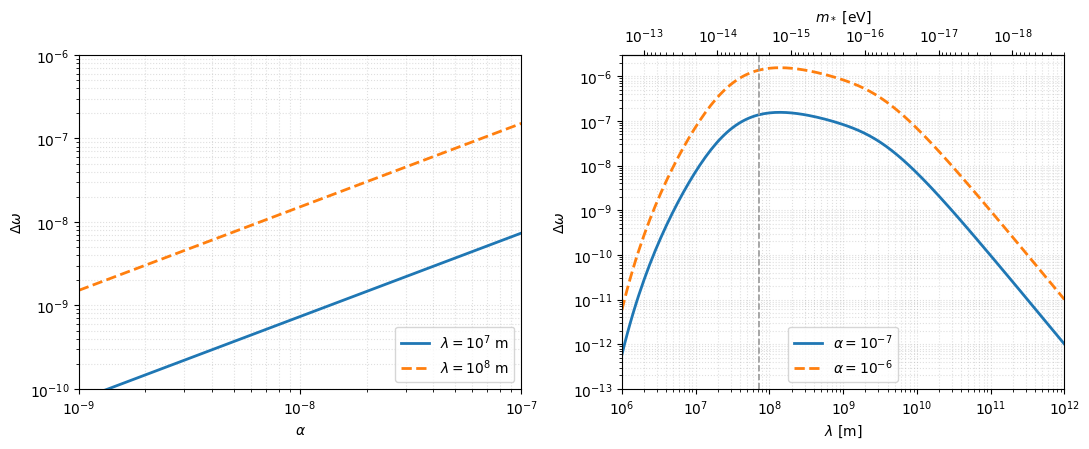

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 4.6))

# left: drift vs coupling alpha, at fixed range lambda
alpha = np.logspace(-9, -7, 50)
for lam0, ls in [(1e7, "C0-"), (1e8, "C1--")]:
    axL.loglog(alpha, alpha * abs(g_finite_size(lam0)), ls, lw=2.0,
               label=rf"$\lambda = 10^{{{int(np.log10(lam0))}}}$ m")
style_log(axL, (1e-9, 1e-7), (1e-10, 1e-6), r"$\alpha$", r"$\Delta\omega$",
          decades(-9, -7), decades(-10, -6))
axL.legend(loc="lower right")

# right: drift vs range lambda, at fixed coupling alpha
lam = np.logspace(6, 12, 160)
g = np.abs(g_finite_size(lam))
for a0, ls in [(1e-7, "C0-"), (1e-6, "C1--")]:
    axR.loglog(lam, a0 * g, ls, lw=2.0, label=rf"$\alpha = 10^{{{int(np.log10(a0))}}}$")
axR.axvline(R_J_M, ls="--", color="0.6", lw=1.2)
style_log(axR, (1e6, 1e12), (1e-13, 3e-6), r"$\lambda$ [m]", r"$\Delta\omega$",
          decades(6, 12), decades(-13, -6))
axR.legend(loc="lower center")
add_mass_axis(axR, range(-13, -19, -1))

fig.tight_layout(); plt.show()

## Figure 4 - Juno fifth-force bound

`alpha_limit(lambda) = sigma_omega / |g(lambda)|`: the smallest detectable coupling at each range.

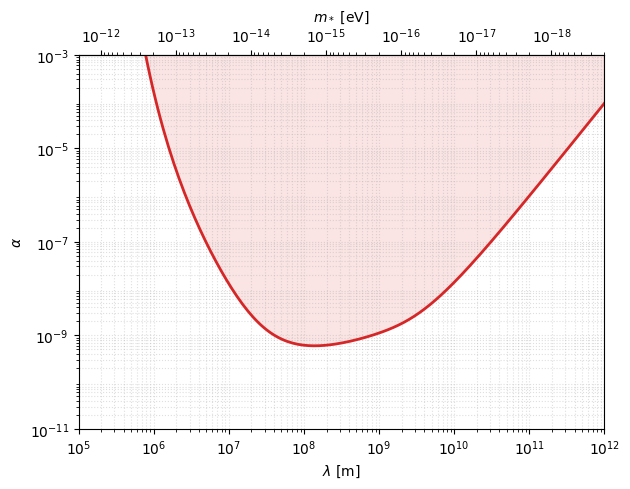

best bound: alpha >~ 5.98e-10 at lambda = 1.35e+08 m


In [7]:
lam = np.logspace(5, 12, 200)
alpha_limit = SIGMA_OMEGA / np.abs(g_finite_size(lam))

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_limit, "C3-", lw=2.0)
ax.fill_between(lam, alpha_limit, 1e-3, color="C3", alpha=0.12)  # excluded region
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
fig.tight_layout(); plt.show()

i = int(np.argmin(alpha_limit))
print(f"best bound: alpha >~ {alpha_limit[i]:.2e} at lambda = {lam[i]:.2e} m")

## Comparison with the updated covariance (Kaspi et al. 2023)

The `[GM, J2..J10]` block below is sliced from the updated covariance of Kaspi et, al. (https://www.nature.com/articles/s41550-023-02077-8). We run the same pipeline on both matrices as-is and compare the 95% C.L. bound (`2 sigma_omega / |g|`) via overlay. The old/new improvement is assuming that a direct comparision between the raw values of the matrix when truncated to only include the relevant 10 by 10 subsection is allowed.

sigma_omega  old (Durante) = 9.332e-10
sigma_omega  new (PJ37)    = 3.523e-10
  improvement factor = 2.65x


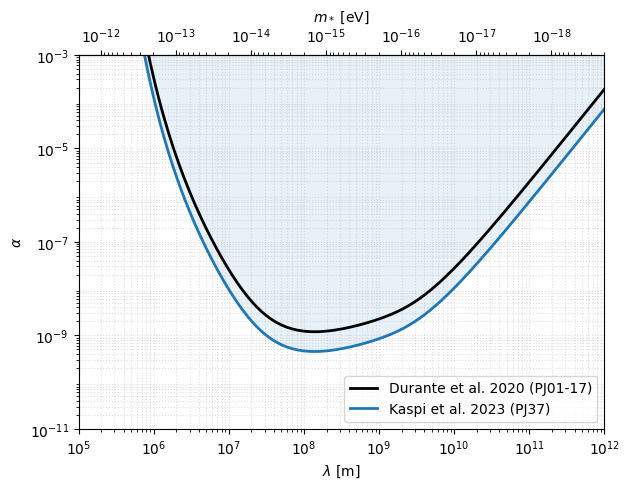

best bound old: alpha >~ 1.20e-09 at lambda = 1.35e+08 m
best bound new: alpha >~ 4.52e-10 at lambda = 1.35e+08 m
  alpha_min improvement factor = 2.65x


In [8]:
# [GM, J2..J10] block sliced from the updated solution from Kaspi that uses 37 perijoves.
COV_GM_J_NEW = np.array([
    [6.4513, 1.5341e-10, -8.1902e-11, 2.4929e-11, -2.1564e-11, 2.9784e-11, 2.4965e-13, 1.8789e-11, 1.8533e-11, -9.9771e-13],
    [1.5341e-10, 1.2282e-19, -2.7792e-20, -3.1090e-20, -2.8738e-20, 4.9996e-21, -4.5955e-20, 6.4584e-21, -3.2191e-20, 1.2000e-20],
    [-8.1902e-11, -2.7792e-20, 1.5058e-19, -3.4613e-20, 2.5293e-20, -7.6736e-20, 6.1071e-20, -1.1847e-19, 6.4399e-20, -1.0093e-19],
    [2.4929e-11, -3.1090e-20, -3.4613e-20, 1.0693e-19, -4.9797e-20, 6.1540e-20, -9.4627e-20, 9.3630e-20, -1.3475e-19, 7.2188e-20],
    [-2.1564e-11, -2.8738e-20, 2.5293e-20, -4.9797e-20, 1.5313e-19, -1.3578e-19, 1.8105e-19, -2.0490e-19, 2.2052e-19, -2.2749e-19],
    [2.9784e-11, 4.9996e-21, -7.6736e-20, 6.1540e-20, -1.3578e-19, 2.9813e-19, -3.3425e-19, 4.3801e-19, -4.4101e-19, 4.4977e-19],
    [2.4965e-13, -4.5955e-20, 6.1071e-20, -9.4627e-20, 1.8105e-19, -3.3425e-19, 6.5354e-19, -7.3508e-19, 9.1248e-19, -8.0954e-19],
    [1.8789e-11, 6.4584e-21, -1.1847e-19, 9.3630e-20, -2.0490e-19, 4.3801e-19, -7.3508e-19, 1.2007e-18, -1.2972e-18, 1.4534e-18],
    [1.8533e-11, -3.2191e-20, 6.4399e-20, -1.3475e-19, 2.2052e-19, -4.4101e-19, 9.1248e-19, -1.2972e-18, 1.8493e-18, -1.8084e-18],
    [-9.9771e-13, 1.2000e-20, -1.0093e-19, 7.2188e-20, -2.2749e-19, 4.4977e-19, -8.0954e-19, 1.4534e-18, -1.8084e-18, 2.3855e-18],
])

grad_cmp = gradient_vector(A_KM, ECC, INC, OMEGA, R_J_KM, N_MAX, apply_normalization=False)
SIGMA_OMEGA_NEW = np.sqrt(grad_cmp @ COV_GM_J_NEW @ grad_cmp)
print(f"sigma_omega  old (Durante) = {SIGMA_OMEGA:.3e}")
print(f"sigma_omega  new (PJ37)    = {SIGMA_OMEGA_NEW:.3e}")
print(f"  improvement factor = {SIGMA_OMEGA / SIGMA_OMEGA_NEW:.2f}x")

lam = np.logspace(5, 12, 200)
g_abs = np.abs(g_finite_size(lam))
alpha_old = 2.0 * SIGMA_OMEGA / g_abs
alpha_new = 2.0 * SIGMA_OMEGA_NEW / g_abs

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_old, "k-", lw=2.0, label="Durante et al. 2020 (PJ01-17)")
ax.loglog(lam, alpha_new, "C0-", lw=2.0, label="Kaspi et al. 2023 (PJ37)")
ax.fill_between(lam, alpha_new, 1e-3, color="C0", alpha=0.10)
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

io, inw = int(np.argmin(alpha_old)), int(np.argmin(alpha_new))
print(f"best bound old: alpha >~ {alpha_old[io]:.2e} at lambda = {lam[io]:.2e} m")
print(f"best bound new: alpha >~ {alpha_new[inw]:.2e} at lambda = {lam[inw]:.2e} m")
print(f"  alpha_min improvement factor = {alpha_old[io] / alpha_new[inw]:.2f}x")

## Figure 3 (right): `sigma_omega` versus harmonic truncation `N`

Reproduces the right panel of Fig. 3 (Singh et al. JHEP 01 (2025) 098): `sigma_omega`
for the conservative first-orbit geometry `i = 1.57, omega = 3.08`, as a function of how
many zonal harmonics `J_l` are kept in the covariance contraction. It rises from
`~0.81e-9` at `N=2` and saturates near `~0.935e-9` by `N~12`, flat out to `N=30`.

The Appendix-B derivatives above only cover `l = 2..10`. To reach `N = 30` we use the
**Gauss planetary-equations** model translated from the Mathematica notebook `J_calc.nb`:
the perturbing force from the zonal potential is projected onto radial/transverse/normal
components and fed into the secularly-averaged Gauss equations for `Omega` and `omega`.
It reproduces `B.1-B.9` to `~1e-14` and extends to arbitrary `l`.

In [9]:
from numpy.polynomial import legendre as _Leg

def _legP(m, x):
    c = np.zeros(m + 1); c[m] = 1.0
    return _Leg.legval(x, c)

def _legP_deriv(m, x):
    c = np.zeros(m + 1); c[m] = 1.0
    return _Leg.legval(x, _Leg.legder(c))

def domega_dJl_gauss(m, a=A_KM, e=ECC, inc=INC, omega=OMEGA, RJ=R_J_KM, n_f=20000):
    """d<Delta omega_g>/dJ_m (per orbit), Gauss planetary-equations model from J_calc.nb.

    The zonal potential U_m = -(mu/r)(RJ/r)^m P_m(z/r) J_m gives a force that, projected
    onto radial/transverse/normal (R-T-N) components with z -> r sin(i) sin(theta), is
        F_R =  (1+m)(RJ/r)^m (mu/r^2) P_m(s)
        F_T = -(RJ/r)^m (mu/r^2) sin(i) cos(theta) P_m'(s)
        F_N = -(RJ/r)^m (mu/r^2) cos(i)            P_m'(s),   s = sin(i) sin(theta).
    (The notebook writes these with P_{m+1}; the Legendre recurrence makes the factor
     (s P_m - P_{m+1})/(s^2-1) = -P_m'(s)/(m+1), regular at the poles s -> +/-1.)
    Secularly averaging the Gauss equations over one orbit (f = theta - omega,
    r = a(1-e^2)/(1+e cos f)) gives the time-averaged rate omega_m; the per-orbit drift
    d<Delta omega>/dJ_m = (2 pi / n) omega_m, in which n and mu cancel.
    """
    theta = np.linspace(0.0, 2.0 * np.pi, n_f)
    f = theta - omega
    cos_f, sin_f = np.cos(f), np.sin(f)
    one_ecf = 1.0 + e * cos_f
    r = a * (1.0 - e**2) / one_ecf
    s = np.sin(inc) * np.sin(theta)
    Pm, dPm = _legP(m, s), _legP_deriv(m, s)
    RJr_m = (RJ / r) ** m
    FR = (1.0 + m) * RJr_m * Pm                       # F_R r^2/mu
    FT = -RJr_m * np.sin(inc) * np.cos(theta) * dPm   # F_T r^2/mu
    FN = -RJr_m * np.cos(inc) * dPm                   # F_N r^2/mu
    term_omega = (-FR * cos_f + FT * (2.0 + e * cos_f) * sin_f / one_ecf) / e
    term_Omega = FN * np.sin(theta) / (np.sin(inc) * one_ecf)
    return float(np.trapezoid(term_omega - np.cos(inc) * term_Omega, theta))

# Cross-check the Gauss model against the analytic Appendix-B coefficients (l = 2..10):
_chk = {l: (domega_dJl(l, A_KM, ECC, INC, OMEGA, R_J_KM), domega_dJl_gauss(l)) for l in (2, 5, 10)}
print("B.l vs Gauss  (l=2,5,10):")
for l, (ana, gau) in _chk.items():
    print(f"  l={l:2d}: {ana: .6e}  vs  {gau: .6e}   rel.err {abs(gau-ana)/abs(ana):.1e}")

B.l vs Gauss  (l=2,5,10):
  l= 2: -1.068185e+00  vs  -1.068185e+00   rel.err 2.1e-16
  l= 5: -3.473286e-02  vs  -3.473286e-02   rel.err 3.0e-15
  l=10: -3.773962e-03  vs  -3.773962e-03   rel.err 9.2e-14


In [10]:
# [GM, J2, ..., J30] block of the Durante covariance (fully-normalised), extended from
# the 10x10 block above so the truncation can be pushed out to N = 30.
COV_GM_J30 = np.array([
    [70.46, 2.318e-09, -4.629e-11, -1.584e-10, -2.058e-11, 2.678e-11, -4.552e-11, 7.314e-11, -1.096e-10, 2.1e-10, -2.722e-10, 5.026e-10, -6.13e-10, 1.049e-09, -1.235e-09, 1.956e-09, -2.212e-09, 3.217e-09, -3.409e-09, 4.479e-09, -4.301e-09, 5.022e-09, -4.203e-09, 4.295e-09, -2.974e-09, 2.602e-09, -1.353e-09, 9.777e-10, -2.961e-10, 1.655e-10],
    [2.318e-09, 5.703e-19, -4.222e-19, 2.918e-19, -3.743e-19, 4.109e-19, -5.579e-19, 6.234e-19, -8.617e-19, 9.329e-19, -1.26e-18, 1.212e-18, -1.58e-18, 1.173e-18, -1.389e-18, 2.53e-19, -8.822e-20, -1.976e-18, 2.395e-18, -4.957e-18, 4.998e-18, -7.095e-18, 6.07e-18, -6.911e-18, 4.853e-18, -4.562e-18, 2.412e-18, -1.84e-18, 5.738e-19, -3.322e-19],
    [-4.629e-11, -4.222e-19, 1.541e-18, -5.734e-19, 1.156e-18, -1.152e-18, 1.814e-18, -2.355e-18, 3.183e-18, -4.705e-18, 5.763e-18, -8.974e-18, 1.017e-17, -1.592e-17, 1.688e-17, -2.588e-17, 2.576e-17, -3.803e-17, 3.539e-17, -4.946e-17, 4.242e-17, -5.493e-17, 4.208e-17, -4.918e-17, 3.183e-17, -3.256e-17, 1.605e-17, -1.381e-17, 3.979e-18, -2.711e-18],
    [-1.584e-10, 2.918e-19, -5.734e-19, 6.411e-19, -7.783e-19, 1.182e-18, -1.416e-18, 2.131e-18, -2.469e-18, 3.625e-18, -3.984e-18, 5.603e-18, -5.577e-18, 7.478e-18, -6.385e-18, 8.284e-18, -5.491e-18, 7.265e-18, -2.729e-18, 4.742e-18, 5.34e-19, 2.402e-18, 2.122e-18, 1.703e-18, 1.394e-18, 1.981e-18, 1.091e-19, 1.56e-18, -1.897e-19, 5.051e-19],
    [-2.058e-11, -3.743e-19, 1.156e-18, -7.783e-19, 1.614e-18, -1.956e-18, 3.27e-18, -4.267e-18, 6.421e-18, -8.559e-18, 1.199e-17, -1.575e-17, 2.072e-17, -2.642e-17, 3.275e-17, -4.009e-17, 4.647e-17, -5.38e-17, 5.74e-17, -6.174e-17, 5.933e-17, -5.818e-17, 4.893e-17, -4.283e-17, 3.013e-17, -2.285e-17, 1.23e-17, -7.696e-18, 2.491e-18, -1.176e-18],
    [2.678e-11, 4.109e-19, -1.152e-18, 1.182e-18, -1.956e-18, 3.418e-18, -4.95e-18, 8.233e-18, -1.134e-17, 1.798e-17, -2.386e-17, 3.611e-17, -4.618e-17, 6.662e-17, -8.158e-17, 1.112e-16, -1.285e-16, 1.631e-16, -1.744e-16, 2.031e-16, -1.96e-16, 2.057e-16, -1.737e-16, 1.608e-16, -1.133e-16, 8.967e-17, -4.805e-17, 3.096e-17, -9.898e-18, 4.735e-18],
    [-4.552e-11, -5.579e-19, 1.814e-18, -1.416e-18, 3.27e-18, -4.95e-18, 9.162e-18, -1.392e-17, 2.286e-17, -3.384e-17, 5.17e-17, -7.392e-17, 1.064e-16, -1.456e-16, 1.97e-16, -2.544e-16, 3.196e-16, -3.83e-16, 4.4e-16, -4.802e-16, 4.944e-16, -4.805e-16, 4.313e-16, -3.622e-16, 2.717e-16, -1.881e-16, 1.087e-16, -5.693e-17, 2.04e-17, -6.597e-18],
    [7.314e-11, 6.234e-19, -2.355e-18, 2.131e-18, -4.267e-18, 8.233e-18, -1.392e-17, 2.529e-17, -3.929e-17, 6.622e-17, -9.756e-17, 1.539e-16, -2.158e-16, 3.185e-16, -4.216e-16, 5.786e-16, -7.132e-16, 9.003e-16, -1.017e-15, 1.164e-15, -1.179e-15, 1.204e-15, -1.063e-15, 9.435e-16, -6.941e-16, 5.155e-16, -2.898e-16, 1.686e-16, -5.752e-17, 2.284e-17],
    [-1.096e-10, -8.617e-19, 3.183e-18, -2.469e-18, 6.421e-18, -1.134e-17, 2.286e-17, -3.929e-17, 6.932e-17, -1.124e-16, 1.819e-16, -2.781e-16, 4.178e-16, -5.994e-16, 8.358e-16, -1.116e-15, 1.432e-15, -1.757e-15, 2.052e-15, -2.279e-15, 2.376e-15, -2.341e-15, 2.124e-15, -1.802e-15, 1.364e-15, -9.519e-16, 5.546e-16, -2.918e-16, 1.054e-16, -3.397e-17],
    [2.1e-10, 9.329e-19, -4.705e-18, 3.625e-18, -8.559e-18, 1.798e-17, -3.384e-17, 6.622e-17, -1.124e-16, 2.001e-16, -3.161e-16, 5.162e-16, -7.625e-16, 1.149e-15, -1.58e-15, 2.191e-15, -2.782e-15, 3.526e-15, -4.075e-15, 4.664e-15, -4.818e-15, 4.894e-15, -4.398e-15, 3.864e-15, -2.891e-15, 2.109e-15, -1.208e-15, 6.802e-16, -2.379e-16, 8.812e-17],
    [-2.722e-10, -1.26e-18, 5.763e-18, -3.984e-18, 1.199e-17, -2.386e-17, 5.17e-17, -9.756e-17, 1.819e-16, -3.161e-16, 5.33e-16, -8.553e-16, 1.324e-15, -1.965e-15, 2.798e-15, -3.827e-15, 4.99e-15, -6.235e-15, 7.365e-15, -8.3e-15, 8.736e-15, -8.711e-15, 7.963e-15, -6.83e-15, 5.202e-15, -3.666e-15, 2.145e-15, -1.141e-15, 4.131e-16, -1.353e-16],
    [5.026e-10, 1.212e-18, -8.974e-18, 5.603e-18, -1.575e-17, 3.611e-17, -7.392e-17, 1.539e-16, -2.781e-16, 5.162e-16, -8.553e-16, 1.438e-15, -2.203e-15, 3.386e-15, -4.788e-15, 6.734e-15, -8.734e-15, 1.118e-14, -1.314e-14, 1.514e-14, -1.586e-14, 1.616e-14, -1.471e-14, 1.292e-14, -9.778e-15, 7.104e-15, -4.115e-15, 2.292e-15, -8.129e-16, 2.922e-16],
    [-6.13e-10, -1.58e-18, 1.017e-17, -5.577e-18, 2.072e-17, -4.618e-17, 1.064e-16, -2.158e-16, 4.178e-16, -7.625e-16, 1.324e-15, -2.203e-15, 3.49e-15, -5.326e-15, 7.729e-15, -1.08e-14, 1.43e-14, -1.819e-14, 2.175e-14, -2.487e-14, 2.643e-14, -2.668e-14, 2.459e-14, -2.132e-14, 1.634e-14, -1.164e-14, 6.844e-15, -3.681e-15, 1.336e-15, -4.446e-16],
    [1.049e-09, 1.173e-18, -1.592e-17, 7.478e-18, -2.642e-17, 6.662e-17, -1.456e-16, 3.185e-16, -5.994e-16, 1.149e-15, -1.965e-15, 3.386e-15, -5.326e-15, 8.354e-15, -1.208e-14, 1.727e-14, -2.283e-14, 2.96e-14, -3.535e-14, 4.114e-14, -4.369e-14, 4.487e-14, -4.128e-14, 3.647e-14, -2.787e-14, 2.03e-14, -1.187e-14, 6.601e-15, -2.364e-15, 8.411e-16],
    [-1.235e-09, -1.389e-18, 1.688e-17, -6.385e-18, 3.275e-17, -8.158e-17, 1.97e-16, -4.216e-16, 8.358e-16, -1.58e-15, 2.798e-15, -4.788e-15, 7.729e-15, -1.208e-14, 1.784e-14, -2.545e-14, 3.421e-14, -4.428e-14, 5.366e-14, -6.228e-14, 6.695e-14, -6.846e-14, 6.369e-14, -5.586e-14, 4.314e-14, -3.105e-14, 1.837e-14, -9.99e-15, 3.64e-15, -1.23e-15],
    [1.956e-09, 2.53e-19, -2.588e-17, 8.284e-18, -4.009e-17, 1.112e-16, -2.544e-16, 5.786e-16, -1.116e-15, 2.191e-15, -3.827e-15, 6.734e-15, -1.08e-14, 1.727e-14, -2.545e-14, 3.702e-14, -4.977e-14, 6.553e-14, -7.948e-14, 9.372e-14, -1.008e-13, 1.047e-13, -9.742e-14, 8.683e-14, -6.7e-14, 4.915e-14, -2.898e-14, 1.619e-14, -5.845e-15, 2.081e-15],
    [-2.212e-09, -8.822e-20, 2.576e-17, -5.491e-18, 4.647e-17, -1.285e-16, 3.196e-16, -7.132e-16, 1.432e-15, -2.782e-15, 4.99e-15, -8.734e-15, 1.43e-14, -2.283e-14, 3.421e-14, -4.977e-14, 6.791e-14, -8.947e-14, 1.099e-13, -1.296e-13, 1.41e-13, -1.462e-13, 1.374e-13, -1.221e-13, 9.511e-14, -6.926e-14, 4.126e-14, -2.272e-14, 8.316e-15, -2.856e-15],
    [3.217e-09, -1.976e-18, -3.803e-17, 7.265e-18, -5.38e-17, 1.631e-16, -3.83e-16, 9.003e-16, -1.757e-15, 3.526e-15, -6.235e-15, 1.118e-14, -1.819e-14, 2.96e-14, -4.428e-14, 6.553e-14, -8.947e-14, 1.197e-13, -1.473e-13, 1.763e-13, -1.921e-13, 2.022e-13, -1.903e-13, 1.716e-13, -1.337e-13, 9.91e-14, -5.893e-14, 3.323e-14, -1.208e-14, 4.34e-15],
    [-3.409e-09, 2.395e-18, 3.539e-17, -2.729e-18, 5.74e-17, -1.744e-16, 4.4e-16, -1.017e-15, 2.052e-15, -4.075e-15, 7.365e-15, -1.314e-14, 2.175e-14, -3.535e-14, 5.366e-14, -7.948e-14, 1.099e-13, -1.473e-13, 1.834e-13, -2.198e-13, 2.421e-13, -2.548e-13, 2.422e-13, -2.181e-13, 1.716e-13, -1.266e-13, 7.604e-14, -4.244e-14, 1.563e-14, -5.466e-15],
    [4.479e-09, -4.957e-18, -4.946e-17, 4.742e-18, -6.174e-17, 2.031e-16, -4.802e-16, 1.164e-15, -2.279e-15, 4.664e-15, -8.3e-15, 1.514e-14, -2.487e-14, 4.114e-14, -6.228e-14, 9.372e-14, -1.296e-13, 1.763e-13, -2.198e-13, 2.671e-13, -2.949e-13, 3.149e-13, -2.998e-13, 2.741e-13, -2.158e-13, 1.621e-13, -9.722e-14, 5.554e-14, -2.033e-14, 7.42e-15],
    [-4.301e-09, 4.998e-18, 4.242e-17, 5.34e-19, 5.933e-17, -1.96e-16, 4.944e-16, -1.179e-15, 2.376e-15, -4.818e-15, 8.736e-15, -1.586e-14, 2.643e-14, -4.369e-14, 6.695e-14, -1.008e-13, 1.41e-13, -1.921e-13, 2.421e-13, -2.949e-13, 3.287e-13, -3.516e-13, 3.379e-13, -3.09e-13, 2.456e-13, -1.84e-13, 1.115e-13, -6.322e-14, 2.342e-14, -8.372e-15],
    [5.022e-09, -7.095e-18, -5.493e-17, 2.402e-18, -5.818e-17, 2.057e-16, -4.805e-16, 1.204e-15, -2.341e-15, 4.894e-15, -8.711e-15, 1.616e-14, -2.668e-14, 4.487e-14, -6.846e-14, 1.047e-13, -1.462e-13, 2.022e-13, -2.548e-13, 3.149e-13, -3.516e-13, 3.815e-13, -3.674e-13, 3.413e-13, -2.715e-13, 2.071e-13, -1.254e-13, 7.288e-14, -2.686e-14, 1.003e-14],
    [-4.203e-09, 6.07e-18, 4.208e-17, 2.122e-18, 4.893e-17, -1.737e-16, 4.313e-16, -1.063e-15, 2.124e-15, -4.398e-15, 7.963e-15, -1.471e-14, 2.459e-14, -4.128e-14, 6.369e-14, -9.742e-14, 1.374e-13, -1.903e-13, 2.422e-13, -2.998e-13, 3.379e-13, -3.674e-13, 3.571e-13, -3.32e-13, 2.666e-13, -2.032e-13, 1.242e-13, -7.181e-14, 2.678e-14, -9.824e-15],
    [4.295e-09, -6.911e-18, -4.918e-17, 1.703e-18, -4.283e-17, 1.608e-16, -3.622e-16, 9.435e-16, -1.802e-15, 3.864e-15, -6.83e-15, 1.292e-14, -2.132e-14, 3.647e-14, -5.586e-14, 8.683e-14, -1.221e-13, 1.716e-13, -2.181e-13, 2.741e-13, -3.09e-13, 3.413e-13, -3.32e-13, 3.14e-13, -2.523e-13, 1.963e-13, -1.199e-13, 7.122e-14, -2.641e-14, 1.017e-14],
    [-2.974e-09, 4.853e-18, 3.183e-17, 1.394e-18, 3.013e-17, -1.133e-16, 2.717e-16, -6.941e-16, 1.364e-15, -2.891e-15, 5.202e-15, -9.778e-15, 1.634e-14, -2.787e-14, 4.314e-14, -6.7e-14, 9.511e-14, -1.337e-13, 1.716e-13, -2.158e-13, 2.456e-13, -2.715e-13, 2.666e-13, -2.523e-13, 2.048e-13, -1.591e-13, 9.821e-14, -5.804e-14, 2.181e-14, -8.254e-15],
    [2.602e-09, -4.562e-18, -3.256e-17, 1.981e-18, -2.285e-17, 8.967e-17, -1.881e-16, 5.155e-16, -9.519e-16, 2.109e-15, -3.666e-15, 7.104e-15, -1.164e-14, 2.03e-14, -3.105e-14, 4.915e-14, -6.926e-14, 9.91e-14, -1.266e-13, 1.621e-13, -1.84e-13, 2.071e-13, -2.032e-13, 1.963e-13, -1.591e-13, 1.267e-13, -7.799e-14, 4.769e-14, -1.777e-14, 7.141e-15],
    [-1.353e-09, 2.412e-18, 1.605e-17, 1.091e-19, 1.23e-17, -4.805e-17, 1.087e-16, -2.898e-16, 5.546e-16, -1.208e-15, 2.145e-15, -4.115e-15, 6.844e-15, -1.187e-14, 1.837e-14, -2.898e-14, 4.126e-14, -5.893e-14, 7.604e-14, -9.722e-14, 1.115e-13, -1.254e-13, 1.242e-13, -1.199e-13, 9.821e-14, -7.799e-14, 4.86e-14, -2.95e-14, 1.116e-14, -4.393e-15],
    [9.777e-10, -1.84e-18, -1.381e-17, 1.56e-18, -7.696e-18, 3.096e-17, -5.693e-17, 1.686e-16, -2.918e-16, 6.802e-16, -1.141e-15, 2.292e-15, -3.681e-15, 6.601e-15, -9.99e-15, 1.619e-14, -2.272e-14, 3.323e-14, -4.244e-14, 5.554e-14, -6.322e-14, 7.288e-14, -7.181e-14, 7.122e-14, -5.804e-14, 4.769e-14, -2.95e-14, 1.878e-14, -7.002e-15, 2.998e-15],
    [-2.961e-10, 5.738e-19, 3.979e-18, -1.897e-19, 2.491e-18, -9.898e-18, 2.04e-17, -5.752e-17, 1.054e-16, -2.379e-16, 4.131e-16, -8.129e-16, 1.336e-15, -2.364e-15, 3.64e-15, -5.845e-15, 8.316e-15, -1.208e-14, 1.563e-14, -2.033e-14, 2.342e-14, -2.686e-14, 2.678e-14, -2.641e-14, 2.181e-14, -1.777e-14, 1.116e-14, -7.002e-15, 2.667e-15, -1.103e-15],
    [1.655e-10, -3.322e-19, -2.711e-18, 5.051e-19, -1.176e-18, 4.735e-18, -6.597e-18, 2.284e-17, -3.397e-17, 8.812e-17, -1.353e-16, 2.922e-16, -4.446e-16, 8.411e-16, -1.23e-15, 2.081e-15, -2.856e-15, 4.34e-15, -5.466e-15, 7.42e-15, -8.372e-15, 1.003e-14, -9.824e-15, 1.017e-14, -8.254e-15, 7.141e-15, -4.393e-15, 2.998e-15, -1.103e-15, 5.289e-16],
])

def gradient_vector_gauss(a, e, inc, omega, RJ, n_max):
    """[d/dmu, d/dJ2, ..., d/dJ_nmax] with the zonal terms from the J_calc.nb Gauss model."""
    grad = [domega_dmu(a, e)]
    for l in range(2, n_max + 1):
        grad.append(domega_dJl_gauss(l, a, e, inc, omega, RJ))
    return np.array(grad)

def sigma_omega_N(n_max):
    g = gradient_vector_gauss(A_KM, ECC, INC, OMEGA, R_J_KM, n_max)
    return float(np.sqrt(g @ COV_GM_J30[:n_max, :n_max] @ g))

# sanity: the J2..J10 block must match the 10x10 COV_GM_J embedded earlier
print(f"COV_GM_J30 vs COV_GM_J (10x10 block) max abs diff = "
      f"{np.max(np.abs(COV_GM_J30[:10, :10] - COV_GM_J)):.2e}")

COV_GM_J30 vs COV_GM_J (10x10 block) max abs diff = 0.00e+00


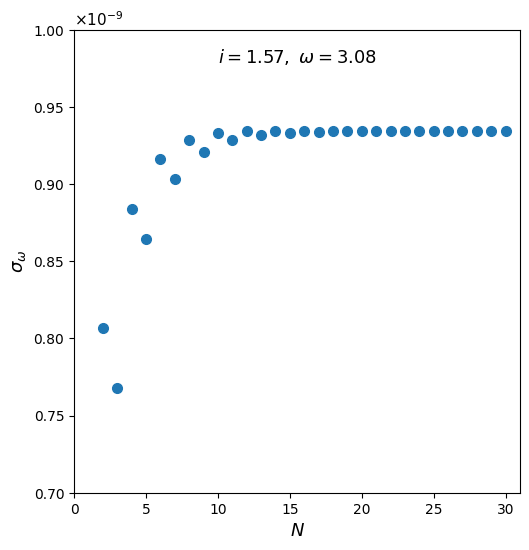

  N= 2: sigma_omega = 8.0667e-10
  N= 3: sigma_omega = 7.6820e-10
  N= 4: sigma_omega = 8.8393e-10
  N= 5: sigma_omega = 8.6436e-10
  N= 6: sigma_omega = 9.1642e-10
  N= 7: sigma_omega = 9.0350e-10
  N= 8: sigma_omega = 9.2874e-10
  N= 9: sigma_omega = 9.2062e-10
  N=10: sigma_omega = 9.3320e-10
  N=11: sigma_omega = 9.2840e-10
  N=12: sigma_omega = 9.3447e-10
  N=13: sigma_omega = 9.3189e-10
  N=14: sigma_omega = 9.3463e-10
  N=15: sigma_omega = 9.3340e-10
  N=16: sigma_omega = 9.3451e-10
  N=17: sigma_omega = 9.3401e-10
  N=18: sigma_omega = 9.3440e-10
  N=19: sigma_omega = 9.3423e-10
  N=20: sigma_omega = 9.3434e-10
  N=21: sigma_omega = 9.3430e-10
  N=22: sigma_omega = 9.3432e-10
  N=23: sigma_omega = 9.3431e-10
  N=24: sigma_omega = 9.3432e-10
  N=25: sigma_omega = 9.3432e-10
  N=26: sigma_omega = 9.3432e-10
  N=27: sigma_omega = 9.3432e-10
  N=28: sigma_omega = 9.3432e-10
  N=29: sigma_omega = 9.3432e-10
  N=30: sigma_omega = 9.3432e-10

plateau (N>=12) sigma_omega = 9.3416e-10  

In [11]:
N = np.arange(2, 31)
sig = np.array([sigma_omega_N(n) for n in N])

fig, ax = plt.subplots(figsize=(5.4, 5.6))
ax.plot(N, sig / 1e-9, "o", color="#1f77b4", ms=7)
ax.set_xlim(0, 31)
ax.set_ylim(0.70, 1.00)
ax.set_xlabel(r"$N$", fontsize=13)
ax.set_ylabel(r"$\sigma_\omega$", fontsize=13)
ax.text(0.5, 0.93, rf"$i = {INC},\ \omega = {OMEGA}$",
        transform=ax.transAxes, ha="center", fontsize=13)
ax.text(0.0, 1.01, r"$\times 10^{-9}$", transform=ax.transAxes, fontsize=11)
fig.tight_layout()
plt.show()

for n, s in zip(N, sig):
    print(f"  N={n:2d}: sigma_omega = {s:.4e}")
print(f"\nplateau (N>=12) sigma_omega = {sig[N >= 12].mean():.4e}  "
      f"(paper Fig. 3 right ~0.935e-9)")

## Figure 3 (right) for the updated matrix (Kaspi et al. 2023, PJ37)

The same `sigma_omega` vs harmonic-truncation `N` curve, but contracting the gradient
with the **updated PJ37 covariance** instead of Durante 2020. We embed the
`[GM, J2..J30]` block of the new solution and overlay both curves so the improvement
is visible at every truncation. The new solution drives `sigma_omega` down by ~2.6x.

In [12]:
# [GM, J2, ..., J30] block of the updated PJ37 solution (Kaspi et al. 2023),
# same fully-normalised basis as Durante; extended from the 10x10 COV_GM_J_NEW above.
COV_GM_J30_NEW = np.array([
    [6.451264483898, 1.534080842857e-10, -8.190238344748e-11, 2.492885185902e-11, -2.156417998584e-11, 2.978442783574e-11, 2.496509998339e-13, 1.878926285444e-11, 1.853333450462e-11, -9.977106731595e-13, 8.719951025096e-12, 6.028440149262e-14, -3.042026464052e-13, -3.584743369499e-14, 2.658715154555e-13, -6.219658688192e-13, -9.451064118724e-13, -1.0322219786e-12, -2.171506384478e-12, -2.625480799558e-12, -1.669975927987e-12, -1.196315661837e-12, -8.936985676201e-13, 2.659244173265e-13, 1.089051807185e-12, 1.068269138099e-12, 1.059400058119e-12, 1.019110944107e-12, 6.393750811085e-13, 3.252867800616e-13],
    [1.534080842857e-10, 1.228211367881e-19, -2.779187003751e-20, -3.109029057862e-20, -2.873811362255e-20, 4.999567990766e-21, -4.59545431494e-20, 6.458353783631e-21, -3.219132401696e-20, 1.200030438575e-20, -1.161488900748e-20, -8.832838025914e-23, -1.148104596932e-21, -1.180686517538e-21, -6.606803598107e-22, -1.041857468278e-21, -1.293521437174e-21, -7.336476793016e-22, -4.036326480305e-22, -1.715471442585e-22, 2.593387301633e-22, 3.376556640573e-22, 1.788715060698e-22, 2.138845466305e-22, 2.192317185843e-22, 4.032336853874e-23, -5.99735331164e-23, -1.308286186345e-23, -8.19025320687e-24, -9.222478883197e-23],
    [-8.190238344748e-11, -2.779187003751e-20, 1.505835789941e-19, -3.461326343754e-20, 2.529331608479e-20, -7.673618672841e-20, 6.107087706818e-20, -1.184685929467e-19, 6.439928869931e-20, -1.009323123581e-19, 4.674890918603e-20, -3.997543651057e-20, 4.320221246118e-21, -1.365957836002e-21, -5.458611039247e-21, -1.258195505675e-22, 9.260484531046e-22, -1.041475075727e-21, 5.875946401481e-22, 9.737155143982e-22, -2.761694425497e-22, 1.893513307432e-22, 6.79176371694e-22, 7.545643621386e-23, -9.232307678115e-23, 2.065282020571e-22, 8.846255754034e-23, -1.361431108536e-22, -2.797333694768e-23, 1.896857452049e-23],
    [2.492885185902e-11, -3.109029057862e-20, -3.461326343754e-20, 1.06934956557e-19, -4.979712697073e-20, 6.153990166577e-20, -9.462718373468e-20, 9.362963516375e-20, -1.347508112974e-19, 7.218846728192e-20, -8.579325771951e-20, 2.515669338291e-20, -1.271807631833e-20, -6.445380883298e-21, 4.118620605568e-21, 3.902399653207e-22, 1.244668410505e-23, 2.53001870686e-21, 8.471695975775e-22, 5.1862328802e-22, 1.114854572734e-21, 1.860931399205e-22, -8.706719361953e-23, 1.669553979422e-22, -1.892658613033e-22, -3.244455958693e-22, -9.936747121246e-23, -1.193337634061e-22, -1.724716070486e-22, -2.481438167953e-23],
    [-2.156417998584e-11, -2.873811362255e-20, 2.529331608479e-20, -4.979712697073e-20, 1.531279165918e-19, -1.357758802384e-19, 1.810457377494e-19, -2.049049050082e-19, 2.20515678483e-19, -2.274861611307e-19, 1.287320562042e-19, -9.904505666116e-20, 1.032731295255e-20, -5.542206781062e-21, -1.255464330876e-20, 7.765159438693e-23, 5.534790159423e-22, -1.447713443981e-21, 1.761794271931e-21, 9.310294738176e-22, 2.39949732452e-22, 1.503712182527e-21, 6.041267923877e-22, -9.236504605306e-23, 5.760408182607e-22, 1.914192091708e-22, -4.165524833427e-22, -3.088301091159e-23, 6.771464724612e-23, -3.239412343259e-22],
    [2.978442783574e-11, 4.999567990766e-21, -7.673618672841e-20, 6.153990166577e-20, -1.357758802384e-19, 2.981293487917e-19, -3.34248768326e-19, 4.380086578041e-19, -4.410107719662e-19, 4.497723473981e-19, -3.247237531166e-19, 1.791860400135e-19, -4.365102470411e-20, -8.566283738527e-21, 2.157509267389e-20, -3.320743098772e-21, -3.159616822576e-21, 6.521172379947e-21, -9.591714293741e-22, -1.125728037727e-21, 2.101330487717e-21, -8.56941131959e-22, -9.370199626507e-22, 7.322837820743e-22, -3.723185586916e-22, -5.966221050704e-22, 3.788687669821e-22, 7.051344895759e-23, -2.554728907865e-22, 2.64029488429e-22],
    [2.496509998339e-13, -4.59545431494e-20, 6.107087706818e-20, -9.462718373468e-20, 1.810457377494e-19, -3.34248768326e-19, 6.535369278773e-19, -7.350813937199e-19, 9.124815717221e-19, -8.095357313054e-19, 6.689821085586e-19, -3.694907020517e-19, 9.940972899819e-20, 1.296483132598e-20, -5.125129572428e-20, 8.723535777118e-21, 5.239521724089e-21, -1.645326161843e-20, 3.3036613628e-21, 3.44947487927e-21, -5.259354015136e-21, 1.957926398621e-21, 2.997627813723e-21, -1.311644330009e-21, 7.667593522409e-22, 1.820716120762e-21, -3.106746624772e-22, -1.228689012484e-22, 7.111382784278e-22, -2.919000166189e-22],
    [1.878926285444e-11, 6.458353783631e-21, -1.184685929467e-19, 9.362963516375e-20, -2.049049050082e-19, 4.380086578041e-19, -7.350813937199e-19, 1.200673290664e-18, -1.297222559678e-18, 1.45340219716e-18, -1.034454222534e-18, 7.28720578943e-19, -1.620799887985e-19, 1.735450075534e-20, 1.025578076695e-19, -1.730762110423e-20, -2.533054122658e-21, 2.817640177751e-20, -1.046033163763e-20, -6.567651891764e-21, 6.84519627059e-21, -6.684989890324e-21, -5.760612595007e-21, 2.083217994283e-21, -1.805714292513e-21, -2.40040748947e-21, 1.677985323824e-21, 7.692404504846e-22, -7.211010941485e-22, 1.197854606784e-21],
    [1.853333450462e-11, -3.219132401696e-20, 6.439928869931e-20, -1.347508112974e-19, 2.20515678483e-19, -4.410107719662e-19, 9.124815717221e-19, -1.297222559678e-18, 1.849255857446e-18, -1.808395029473e-18, 1.586780211566e-18, -9.115519323433e-19, 2.989742070255e-19, 2.224065699253e-20, -1.197222169021e-19, 3.911693224122e-20, 6.582033895535e-21, -3.967078888157e-20, 1.167085657988e-20, 3.754778501353e-21, -1.411405190443e-20, 5.34409943801e-21, 4.649412746746e-21, -4.486025127708e-21, 2.235631700633e-21, 3.643157688297e-21, -1.344913820844e-21, 7.76400076751e-23, 1.656978255443e-21, -8.536054223553e-22],
    [-9.977106731595e-13, 1.200030438575e-20, -1.009323123581e-19, 7.218846728192e-20, -2.274861611307e-19, 4.497723473981e-19, -8.095357313054e-19, 1.45340219716e-18, -1.808395029473e-18, 2.385494842267e-18, -1.814830744668e-18, 1.429578832994e-18, -3.452744625504e-19, 9.380046085756e-20, 2.042416238487e-19, -3.408181069102e-20, 1.602076375581e-20, 5.432589230464e-20, -2.125907125046e-20, -7.026313458327e-21, 1.09333902398e-20, -1.572467379379e-20, -1.020968836681e-20, 2.612378596198e-21, -5.639261721764e-21, -4.531745712883e-21, 3.350074106151e-21, 8.886129222782e-22, -1.242879403416e-21, 2.748554859804e-21],
    [8.719951025096e-12, -1.161488900748e-20, 4.674890918603e-20, -8.579325771951e-20, 1.287320562042e-19, -3.247237531166e-19, 6.689821085586e-19, -1.034454222534e-18, 1.586780211566e-18, -1.814830744668e-18, 1.875321133383e-18, -1.194629405579e-18, 4.904021798823e-19, -1.592966260185e-20, -1.374258698605e-19, 7.330243734421e-20, -2.185465729211e-21, -4.541833870981e-20, 2.118792804133e-20, 5.234932957466e-22, -1.75967023883e-20, 8.346279155274e-21, 3.473207964899e-21, -6.724367513314e-21, 3.223300229711e-21, 3.596949715585e-21, -2.445605046425e-21, 3.737297479309e-22, 1.925201022748e-21, -1.218480930138e-21],
    [6.028440149262e-14, -8.832838025914e-23, -3.997543651057e-20, 2.515669338291e-20, -9.904505666116e-20, 1.791860400135e-19, -3.694907020517e-19, 7.28720578943e-19, -9.115519323433e-19, 1.429578832994e-18, -1.194629405579e-18, 1.290935694126e-18, -3.723255167491e-19, 2.302737585196e-19, 1.779285354191e-19, -2.38138349806e-20, 5.305698937387e-20, 4.774786245376e-20, -1.983132123318e-20, 2.724893081843e-21, 6.336317435949e-21, -1.837313263857e-20, -8.377811892618e-21, -1.880692490156e-22, -8.011974958493e-21, -3.988764195072e-21, 2.769438368676e-21, 1.0313369289e-22, -6.291765357943e-22, 2.966266025751e-21],
    [-3.042026464052e-13, -1.148104596932e-21, 4.320221246118e-21, -1.271807631833e-20, 1.032731295255e-20, -4.365102470411e-20, 9.940972899819e-20, -1.620799887985e-19, 2.989742070255e-19, -3.452744625504e-19, 4.904021798823e-19, -3.723255167491e-19, 3.582126247983e-19, -9.096594349655e-20, 5.193860150915e-20, 5.344196151247e-20, -4.33860927914e-21, 1.111325263121e-20, 1.559389411436e-20, -4.968501877983e-21, -1.447426746656e-21, 2.453713911234e-21, -4.803674834802e-21, -3.521332319001e-21, 3.203265262791e-23, -1.843516478867e-21, -1.47497986956e-21, 5.317909901874e-22, -1.230438750266e-22, 3.360884519262e-23],
    [-3.584743369499e-14, -1.180686517538e-21, -1.365957836002e-21, -6.445380883298e-21, -5.542206781062e-21, -8.566283738527e-21, 1.296483132598e-20, 1.735450075534e-20, 2.224065699253e-20, 9.380046085756e-20, -1.592966260185e-20, 2.302737585196e-19, -9.096594349655e-20, 2.576905837343e-19, -3.630639642159e-20, 8.346221564157e-20, 4.730122888375e-20, 6.763380296895e-21, 1.999256860157e-20, 1.130885939781e-20, -5.137133151426e-21, -1.26529399633e-21, -1.551579730486e-21, -6.828956637228e-21, -4.154036724205e-21, -1.456951834515e-21, -2.185644469692e-21, -1.009037625964e-21, 4.017573556652e-22, 4.234240470521e-22],
    [2.658715154555e-13, -6.606803598107e-22, -5.458611039247e-21, 4.118620605568e-21, -1.255464330876e-20, 2.157509267389e-20, -5.125129572428e-20, 1.025578076695e-19, -1.197222169021e-19, 2.042416238487e-19, -1.374258698605e-19, 1.779285354191e-19, 5.193860150915e-20, -3.630639642159e-20, 2.113981693992e-19, -5.474677086315e-20, 7.993542032629e-20, 4.047520685797e-20, -4.991985354548e-22, 2.060735277333e-20, 1.141586447224e-20, -6.939789182021e-21, -3.25631532981e-22, -1.529771413254e-22, -6.982984521452e-21, -3.751382967104e-21, -3.874485399238e-22, -2.06649833438e-21, -1.283722214209e-21, 1.033333802264e-21],
    [-6.219658688192e-13, -1.041857468278e-21, -1.258195505675e-22, 3.902399653207e-22, 7.765159438693e-23, -3.320743098772e-21, 8.723535777118e-21, -1.730762110423e-20, 3.911693224122e-20, -3.408181069102e-20, 7.330243734421e-20, -2.38138349806e-20, 5.344196151247e-20, 8.346221564157e-20, -5.474677086315e-20, 1.735548836394e-19, -4.7504780102e-20, 6.795461173128e-20, 3.36281845937e-20, 1.51656418741e-21, 1.853614492773e-20, 1.039501710314e-20, -5.128786171696e-21, -3.572799919342e-22, -2.75180678658e-22, -6.049709942437e-21, -3.572986709796e-21, -7.701387264513e-22, -2.277285125333e-21, -8.173176127462e-22],
    [-9.451064118724e-13, -1.293521437174e-21, 9.260484531046e-22, 1.244668410505e-23, 5.534790159423e-22, -3.159616822576e-21, 5.239521724089e-21, -2.533054122658e-21, 6.582033895535e-21, 1.602076375581e-20, -2.185465729211e-21, 5.305698937387e-20, -4.33860927914e-21, 4.730122888375e-20, 7.993542032629e-20, -4.7504780102e-20, 1.553318317416e-19, -4.297606164716e-20, 6.284389514966e-20, 3.12024176825e-20, 9.732239331104e-22, 1.670266169774e-20, 9.629657471055e-21, -5.457088851595e-21, -1.143589240143e-21, -1.76657662497e-22, -5.577775341434e-21, -3.278326337421e-21, 2.485160449052e-24, -1.966547729815e-21],
    [-1.0322219786e-12, -7.336476793016e-22, -1.041475075727e-21, 2.53001870686e-21, -1.447713443981e-21, 6.521172379947e-21, -1.645326161843e-20, 2.817640177751e-20, -3.967078888157e-20, 5.432589230464e-20, -4.541833870981e-20, 4.774786245376e-20, 1.111325263121e-20, 6.763380296895e-21, 4.047520685797e-20, 6.795461173128e-20, -4.297606164716e-20, 1.393403645985e-19, -4.098693590335e-20, 5.745626030424e-20, 2.93358676447e-20, 3.222882880424e-22, 1.486513303054e-20, 9.24541178458e-21, -5.173517061189e-21, -1.596078114998e-21, -6.277667783834e-24, -4.342236311725e-21, -2.246778044244e-21, -3.88245651982e-22],
    [-2.171506384478e-12, -4.036326480305e-22, 5.875946401481e-22, 8.471695975775e-22, 1.761794271931e-21, -9.591714293741e-22, 3.3036613628e-21, -1.046033163763e-20, 1.167085657988e-20, -2.125907125046e-20, 2.118792804133e-20, -1.983132123318e-20, 1.559389411436e-20, 1.999256860157e-20, -4.991985354548e-22, 3.36281845937e-20, 6.284389514966e-20, -4.098693590335e-20, 1.253967209458e-19, -3.676030122384e-20, 5.208138302696e-20, 2.759212660114e-20, 6.356306808765e-22, 1.290099771245e-20, 8.70709320598e-21, -4.815268126716e-21, -2.489200655019e-21, -1.029233769255e-22, -3.729354432633e-21, -2.765158113546e-21],
    [-2.625480799558e-12, -1.715471442585e-22, 9.737155143982e-22, 5.1862328802e-22, 9.310294738176e-22, -1.125728037727e-21, 3.44947487927e-21, -6.567651891764e-21, 3.754778501353e-21, -7.026313458327e-21, 5.234932957466e-22, 2.724893081843e-21, -4.968501877983e-21, 1.130885939781e-20, 2.060735277333e-20, 1.51656418741e-21, 3.12024176825e-20, 5.745626030424e-20, -3.676030122384e-20, 1.14380779046e-19, -3.377227382101e-20, 4.736688491634e-20, 2.584612712706e-20, 2.125628901525e-23, 1.122954516532e-20, 8.46647433197e-21, -4.720394998874e-21, -2.11609231338e-21, 1.668698588442e-21, -4.466188276247e-21],
    [-1.669975927987e-12, 2.593387301633e-22, -2.761694425497e-22, 1.114854572734e-21, 2.39949732452e-22, 2.101330487717e-21, -5.259354015136e-21, 6.84519627059e-21, -1.411405190443e-20, 1.09333902398e-20, -1.75967023883e-20, 6.336317435949e-21, -1.447426746656e-21, -5.137133151426e-21, 1.141586447224e-20, 1.853614492773e-20, 9.732239331104e-22, 2.93358676447e-20, 5.208138302696e-20, -3.377227382101e-20, 1.049835146149e-19, -3.056285127618e-20, 4.262791384203e-20, 2.41404834578e-20, 5.406359695258e-22, 9.837779413547e-21, 7.592387664342e-21, -2.915317192012e-21, -8.006217702896e-23, -1.851970286754e-22],
    [-1.196315661837e-12, 3.376556640573e-22, 1.893513307432e-22, 1.860931399205e-22, 1.503712182527e-21, -8.56941131959e-22, 1.957926398621e-21, -6.684989890324e-21, 5.34409943801e-21, -1.572467379379e-20, 8.346279155274e-21, -1.837313263857e-20, 2.453713911234e-21, -1.26529399633e-21, -6.939789182021e-21, 1.039501710314e-20, 1.670266169774e-20, 3.222882880424e-22, 2.759212660114e-20, 4.736688491634e-20, -3.056285127618e-20, 9.734004739048e-20, -2.744128219385e-20, 3.852838137011e-20, 2.308906871885e-20, 4.276616735002e-22, 7.48360500345e-21, 6.634415031102e-21, -2.743870856248e-21, -1.41123853221e-21],
    [-8.936985676201e-13, 1.788715060698e-22, 6.79176371694e-22, -8.706719361953e-23, 6.041267923877e-22, -9.370199626507e-22, 2.997627813723e-21, -5.760612595007e-21, 4.649412746746e-21, -1.020968836681e-20, 3.473207964899e-21, -8.377811892618e-21, -4.803674834802e-21, -1.551579730486e-21, -3.25631532981e-22, -5.128786171696e-21, 9.629657471055e-21, 1.486513303054e-20, 6.356306808765e-22, 2.584612712706e-20, 4.262791384203e-20, -2.744128219385e-20, 9.024735149507e-20, -2.498438930889e-20, 3.515866583744e-20, 2.230982276585e-20, 1.701177855935e-22, 6.375487110483e-21, 7.366702002913e-21, -3.538204830426e-21],
    [2.659244173265e-13, 2.138845466305e-22, 7.545643621386e-23, 1.669553979422e-22, -9.236504605306e-23, 7.322837820743e-22, -1.311644330009e-21, 2.083217994283e-21, -4.486025127708e-21, 2.612378596198e-21, -6.724367513314e-21, -1.880692490156e-22, -3.521332319001e-21, -6.828956637228e-21, -1.529771413254e-22, -3.572799919342e-22, -5.457088851595e-21, 9.24541178458e-21, 1.290099771245e-20, 2.125628901525e-23, 2.41404834578e-20, 3.852838137011e-20, -2.498438930889e-20, 8.358487355963e-20, -2.198613740212e-20, 3.235631448398e-20, 2.115701180232e-20, 1.513434839002e-21, 7.402527041889e-21, 5.492745949968e-21],
    [1.089051807185e-12, 2.192317185843e-22, -9.232307678115e-23, -1.892658613033e-22, 5.760408182607e-22, -3.723185586916e-22, 7.667593522409e-22, -1.805714292513e-21, 2.235631700633e-21, -5.639261721764e-21, 3.223300229711e-21, -8.011974958493e-21, 3.203265262791e-23, -4.154036724205e-21, -6.982984521452e-21, -2.75180678658e-22, -1.143589240143e-21, -5.173517061189e-21, 8.70709320598e-21, 1.122954516532e-20, 5.406359695258e-22, 2.308906871885e-20, 3.515866583744e-20, -2.198613740212e-20, 7.708292789589e-20, -2.071271857833e-20, 2.891476708904e-20, 1.77625915149e-20, -2.156737721444e-21, 7.5634961396e-21],
    [1.068269138099e-12, 4.032336853874e-23, 2.065282020571e-22, -3.244455958693e-22, 1.914192091708e-22, -5.966221050704e-22, 1.820716120762e-21, -2.40040748947e-21, 3.643157688297e-21, -4.531745712883e-21, 3.596949715585e-21, -3.988764195072e-21, -1.843516478867e-21, -1.456951834515e-21, -3.751382967104e-21, -6.049709942437e-21, -1.76657662497e-22, -1.596078114998e-21, -4.815268126716e-21, 8.46647433197e-21, 9.837779413547e-21, 4.276616735002e-22, 2.230982276585e-20, 3.235631448398e-20, -2.071271857833e-20, 7.084463529599e-20, -1.85052752355e-20, 2.343580890535e-20, 1.259364315897e-20, 4.855873832392e-22],
    [1.059400058119e-12, -5.99735331164e-23, 8.846255754034e-23, -9.936747121246e-23, -4.165524833427e-22, 3.788687669821e-22, -3.106746624772e-22, 1.677985323824e-21, -1.344913820844e-21, 3.350074106151e-21, -2.445605046425e-21, 2.769438368676e-21, -1.47497986956e-21, -2.185644469692e-21, -3.874485399238e-22, -3.572986709796e-21, -5.577775341434e-21, -6.277667783834e-24, -2.489200655019e-21, -4.720394998874e-21, 7.592387664342e-21, 7.48360500345e-21, 1.701177855935e-22, 2.115701180232e-20, 2.891476708904e-20, -1.85052752355e-20, 6.666771984076e-20, -1.639478135999e-20, 2.116853975736e-20, 1.317948612499e-20],
    [1.019110944107e-12, -1.308286186345e-23, -1.361431108536e-22, -1.193337634061e-22, -3.088301091159e-23, 7.051344895759e-23, -1.228689012484e-22, 7.692404504846e-22, 7.76400076751e-23, 8.886129222782e-22, 3.737297479309e-22, 1.0313369289e-22, 5.317909901874e-22, -1.009037625964e-21, -2.06649833438e-21, -7.701387264513e-22, -3.278326337421e-21, -4.342236311725e-21, -1.029233769255e-22, -2.11609231338e-21, -2.915317192012e-21, 6.634415031102e-21, 6.375487110483e-21, 1.513434839002e-21, 1.77625915149e-20, 2.343580890535e-20, -1.639478135999e-20, 5.707634565345e-20, -2.374831473092e-20, 2.447537563545e-20],
    [6.393750811085e-13, -8.19025320687e-24, -2.797333694768e-23, -1.724716070486e-22, 6.771464724612e-23, -2.554728907865e-22, 7.111382784278e-22, -7.211010941485e-22, 1.656978255443e-21, -1.242879403416e-21, 1.925201022748e-21, -6.291765357943e-22, -1.230438750266e-22, 4.017573556652e-22, -1.283722214209e-21, -2.277285125333e-21, 2.485160449052e-24, -2.246778044244e-21, -3.729354432633e-21, 1.668698588442e-21, -8.006217702896e-23, -2.743870856248e-21, 7.366702002913e-21, 7.402527041889e-21, -2.156737721444e-21, 1.259364315897e-20, 2.116853975736e-20, -2.374831473092e-20, 3.738362710174e-20, -1.269102336973e-20],
    [3.252867800616e-13, -9.222478883197e-23, 1.896857452049e-23, -2.481438167953e-23, -3.239412343259e-22, 2.64029488429e-22, -2.919000166189e-22, 1.197854606784e-21, -8.536054223553e-22, 2.748554859804e-21, -1.218480930138e-21, 2.966266025751e-21, 3.360884519262e-23, 4.234240470521e-22, 1.033333802264e-21, -8.173176127462e-22, -1.966547729815e-21, -3.88245651982e-22, -2.765158113546e-21, -4.466188276247e-21, -1.851970286754e-22, -1.41123853221e-21, -3.538204830426e-21, 5.492745949968e-21, 7.5634961396e-21, 4.855873832392e-22, 1.317948612499e-20, 2.447537563545e-20, -1.269102336973e-20, 3.198684568553e-20],
])

def sigma_omega_N_new(n_max):
    g = gradient_vector_gauss(A_KM, ECC, INC, OMEGA, R_J_KM, n_max)
    return float(np.sqrt(g @ COV_GM_J30_NEW[:n_max, :n_max] @ g))

# sanity: J2..J10 block must match the 10x10 COV_GM_J_NEW embedded earlier
print(f"COV_GM_J30_NEW vs COV_GM_J_NEW (10x10 block) max abs diff = "
      f"{np.max(np.abs(COV_GM_J30_NEW[:10, :10] - COV_GM_J_NEW)):.2e}")

COV_GM_J30_NEW vs COV_GM_J_NEW (10x10 block) max abs diff = 3.55e-05


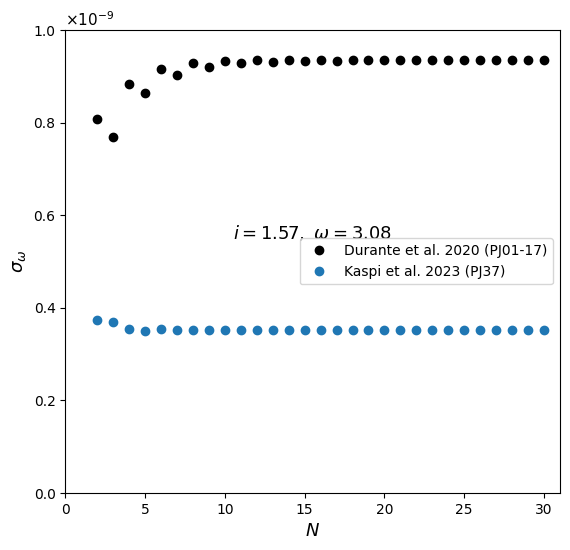

  N   old (Durante)    new (PJ37)   old/new
  2      8.0667e-10    3.7435e-10      2.15
  3      7.6820e-10    3.6939e-10      2.08
  4      8.8393e-10    3.5336e-10      2.50
  5      8.6436e-10    3.4945e-10      2.47
  6      9.1642e-10    3.5334e-10      2.59
  7      9.0350e-10    3.5060e-10      2.58
  8      9.2874e-10    3.5260e-10      2.63
  9      9.2062e-10    3.5164e-10      2.62
 10      9.3320e-10    3.5226e-10      2.65
 11      9.2840e-10    3.5209e-10      2.64
 12      9.3447e-10    3.5214e-10      2.65
 13      9.3189e-10    3.5213e-10      2.65
 14      9.3463e-10    3.5213e-10      2.65
 15      9.3340e-10    3.5213e-10      2.65
 16      9.3451e-10    3.5213e-10      2.65
 17      9.3401e-10    3.5213e-10      2.65
 18      9.3440e-10    3.5213e-10      2.65
 19      9.3423e-10    3.5213e-10      2.65
 20      9.3434e-10    3.5213e-10      2.65
 21      9.3430e-10    3.5213e-10      2.65
 22      9.3432e-10    3.5213e-10      2.65
 23      9.3431e-10    3.5213e-1

In [13]:
N = np.arange(2, 31)
sig_old = np.array([sigma_omega_N(n) for n in N])       # Durante 2020 (defined earlier)
sig_new = np.array([sigma_omega_N_new(n) for n in N])   # Kaspi 2023 (PJ37)

fig, ax = plt.subplots(figsize=(5.8, 5.6))
ax.plot(N, sig_old / 1e-9, "o", color="k",       ms=6, label="Durante et al. 2020 (PJ01-17)")
ax.plot(N, sig_new / 1e-9, "o", color="#1f77b4", ms=6, label="Kaspi et al. 2023 (PJ37)")
ax.set_xlim(0, 31)
ax.set_ylim(0.0, 1.00)
ax.set_xlabel(r"$N$", fontsize=13)
ax.set_ylabel(r"$\sigma_\omega$", fontsize=13)
ax.text(0.5, 0.55, rf"$i = {INC},\ \omega = {OMEGA}$",
        transform=ax.transAxes, ha="center", fontsize=13)
ax.text(0.0, 1.01, r"$\times 10^{-9}$", transform=ax.transAxes, fontsize=11)
ax.legend(loc="center right", frameon=True)
fig.tight_layout()
plt.show()

print(f"{'N':>3} {'old (Durante)':>15} {'new (PJ37)':>13} {'old/new':>9}")
for n, so, sn in zip(N, sig_old, sig_new):
    print(f"{n:>3} {so:15.4e} {sn:13.4e} {so/sn:9.2f}")
print(f"\nplateau (N>=12): old = {sig_old[N>=12].mean():.4e}, "
      f"new = {sig_new[N>=12].mean():.4e}, improvement = "
      f"{sig_old[N>=12].mean()/sig_new[N>=12].mean():.2f}x")